# LeRobotVideoDataset example

Loads `LSY-lab/stack_without_ft_tact_v4` — a LeRobot v2.1 dataset whose camera
streams are external AV1-encoded mp4 files — via the `repo_id=` origin. Only
the two requested episodes are fetched; the other 49 are never downloaded.


In [1]:
from robotdataset import LeRobotVideoDataset, batchViz

/hpcwork/yn030245/venvs/robotdataset-dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load two episodes

`delta_timestamps` requests a 3-frame history (0.6s, 0.3s and 0.0s back) for the
primary camera; every other modality defaults to the anchor step only.

In [2]:
dataset = LeRobotVideoDataset(
    repo_id="LSY-lab/stack_without_ft_tact_v4",
    episodes=[0, 1],
    batch_size=4,
    delta_timestamps={"observation/images/primary": [-0.6, -0.3, 0.0]},
)

print("num_episodes:", dataset.num_episodes)
print("total steps:", len(dataset))
print("fps:", dataset.fps)

Converting episodes to TED:   0%|          | 0/2 [00:00<?, ?ep/s]

Converting episodes to TED:  50%|█████     | 1/2 [00:32<00:32, 32.83s/ep]

Converting episodes to TED: 100%|██████████| 2/2 [00:38<00:00, 16.81s/ep]

Converting episodes to TED: 100%|██████████| 2/2 [00:38<00:00, 19.22s/ep]

Assembling training buffer:   0%|          | 0/2 [00:00<?, ?ep/s]

Assembling training buffer:  50%|█████     | 1/2 [00:01<00:01,  1.35s/ep]

Assembling training buffer: 100%|██████████| 2/2 [00:02<00:00,  1.18s/ep]

Assembling training buffer: 100%|██████████| 2/2 [00:02<00:00,  1.21s/ep]

num_episodes: 2
total steps: 506
fps: 15.0


## Inspect the inferred modalities

In [3]:
for path, spec in sorted(dataset.get_modalities().items()):
    print(f"{path:35s} {spec['kind']:8s} {spec['shape']}")

action                              action   (7,)
collector/episode_id                generic  ()
done                                generic  (1,)
next/done                           generic  (1,)
next/observation/images/primary     image    (256, 256, 3)
next/observation/images/wrist       image    (256, 256, 3)
next/observation/state/all          state    (20,)
next/observation/state/cartesian    state    (6,)
next/observation/state/gripper      state    (1,)
next/observation/state/joints       state    (7,)
next/observation/state/target       state    (6,)
next/reward                         generic  (1,)
next/terminated                     generic  (1,)
observation/images/primary          image    (256, 256, 3)
observation/images/wrist            image    (256, 256, 3)
observation/state/all               state    (20,)
observation/state/cartesian         state    (6,)
observation/state/gripper           state    (1,)
observation/state/joints            state    (7,)
observation/st

## Sample a batch

Images come back channel-first (`B, T, C, H, W`) — the on-disk storage is HWC,
permuted automatically because `observation/images/*` is in `dataset.image_keys`.

In [4]:
batch = dataset.sample()

for key in ("observation/images/primary", "observation/images/wrist",
            "observation/state/cartesian", "action"):
    print(f"{key:35s} {tuple(batch[key].shape)}")

observation/images/primary          (4, 3, 3, 256, 256)
observation/images/wrist            (4, 1, 3, 256, 256)
observation/state/cartesian         (4, 1, 6)
action                              (4, 1, 7)


## Visualize the sampled window

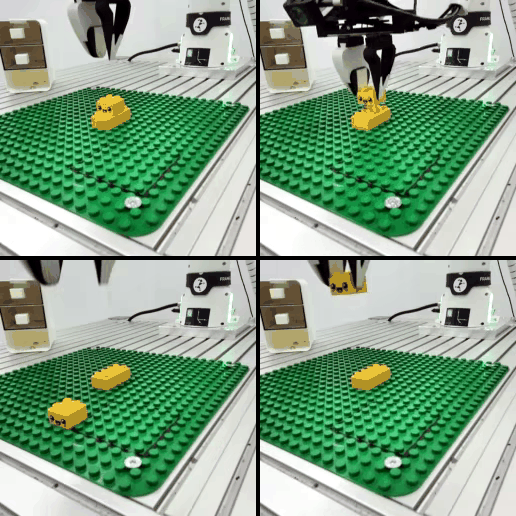

In [5]:
batchViz(batch, key="observation/images/primary", fps=4)